SHAPE E INFO
(216, 5)
<class 'pandas.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   categoria                216 non-null    str           
 1   anno                     216 non-null    int64         
 2   mese                     216 non-null    int64         
 3   data_mese                216 non-null    datetime64[us]
 4   quantita_totale_venduta  216 non-null    int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 8.6 KB

PRIME RIGHE
       categoria  anno  mese  data_mese  quantita_totale_venduta
0  Abbigliamento  2023     1 2023-01-01                       52
1  Abbigliamento  2023     2 2023-02-01                       51
2  Abbigliamento  2023     3 2023-03-01                       62
3  Abbigliamento  2023     4 2023-04-01                       57
4  Abbigliamento  2023     5 2023-05-01                

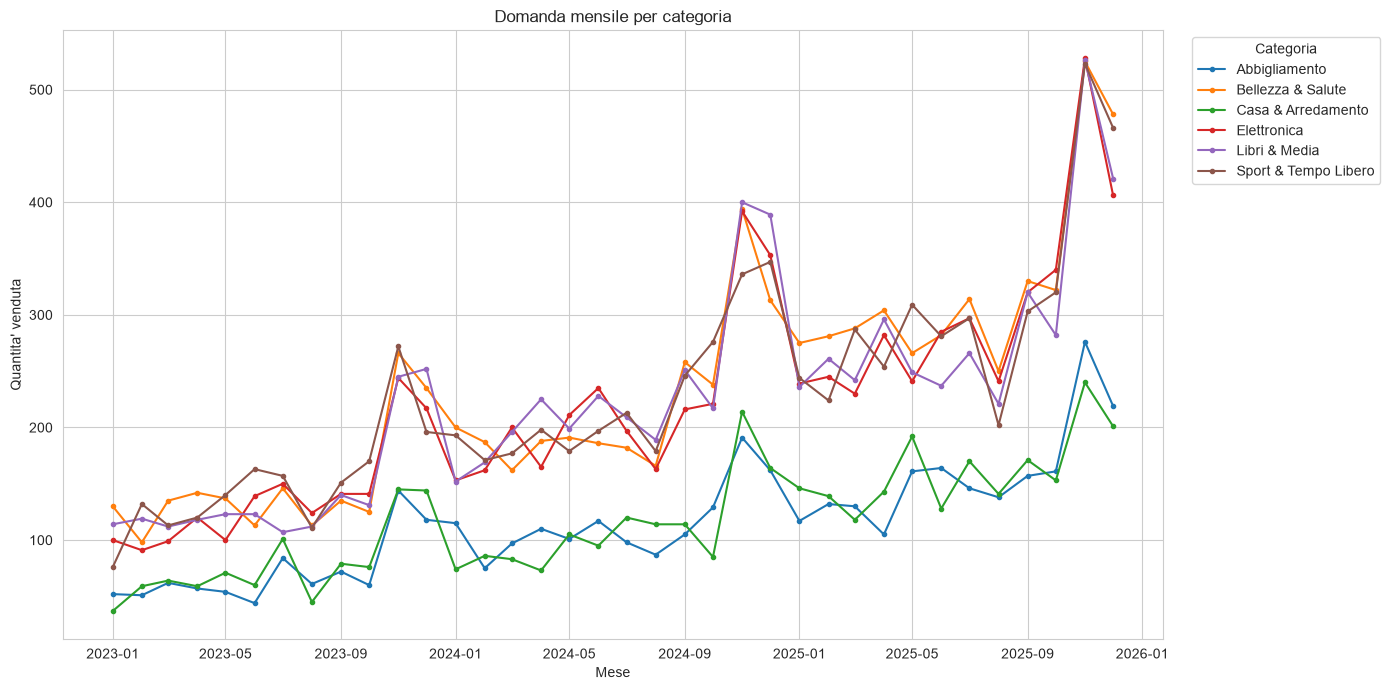

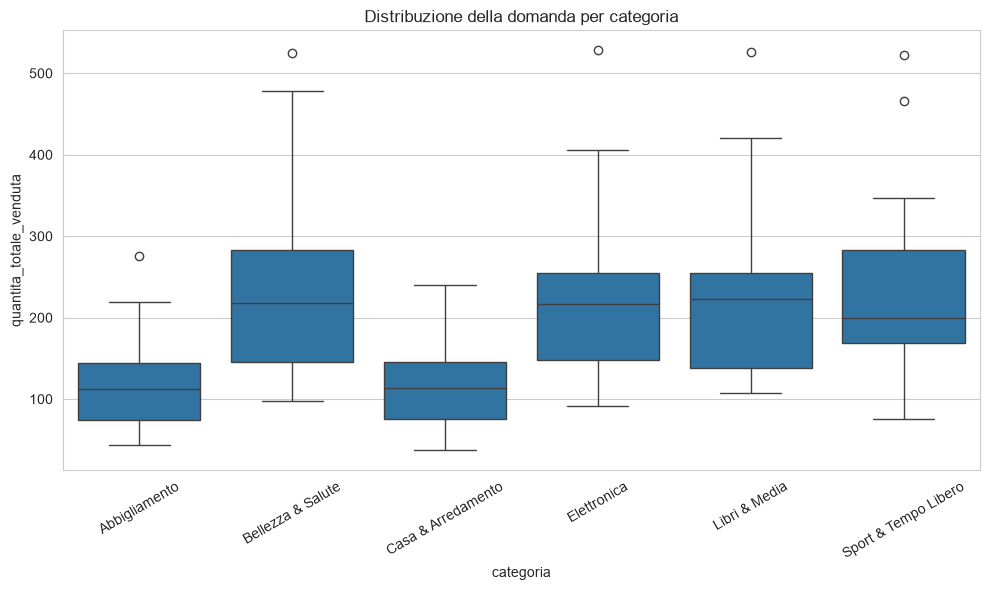

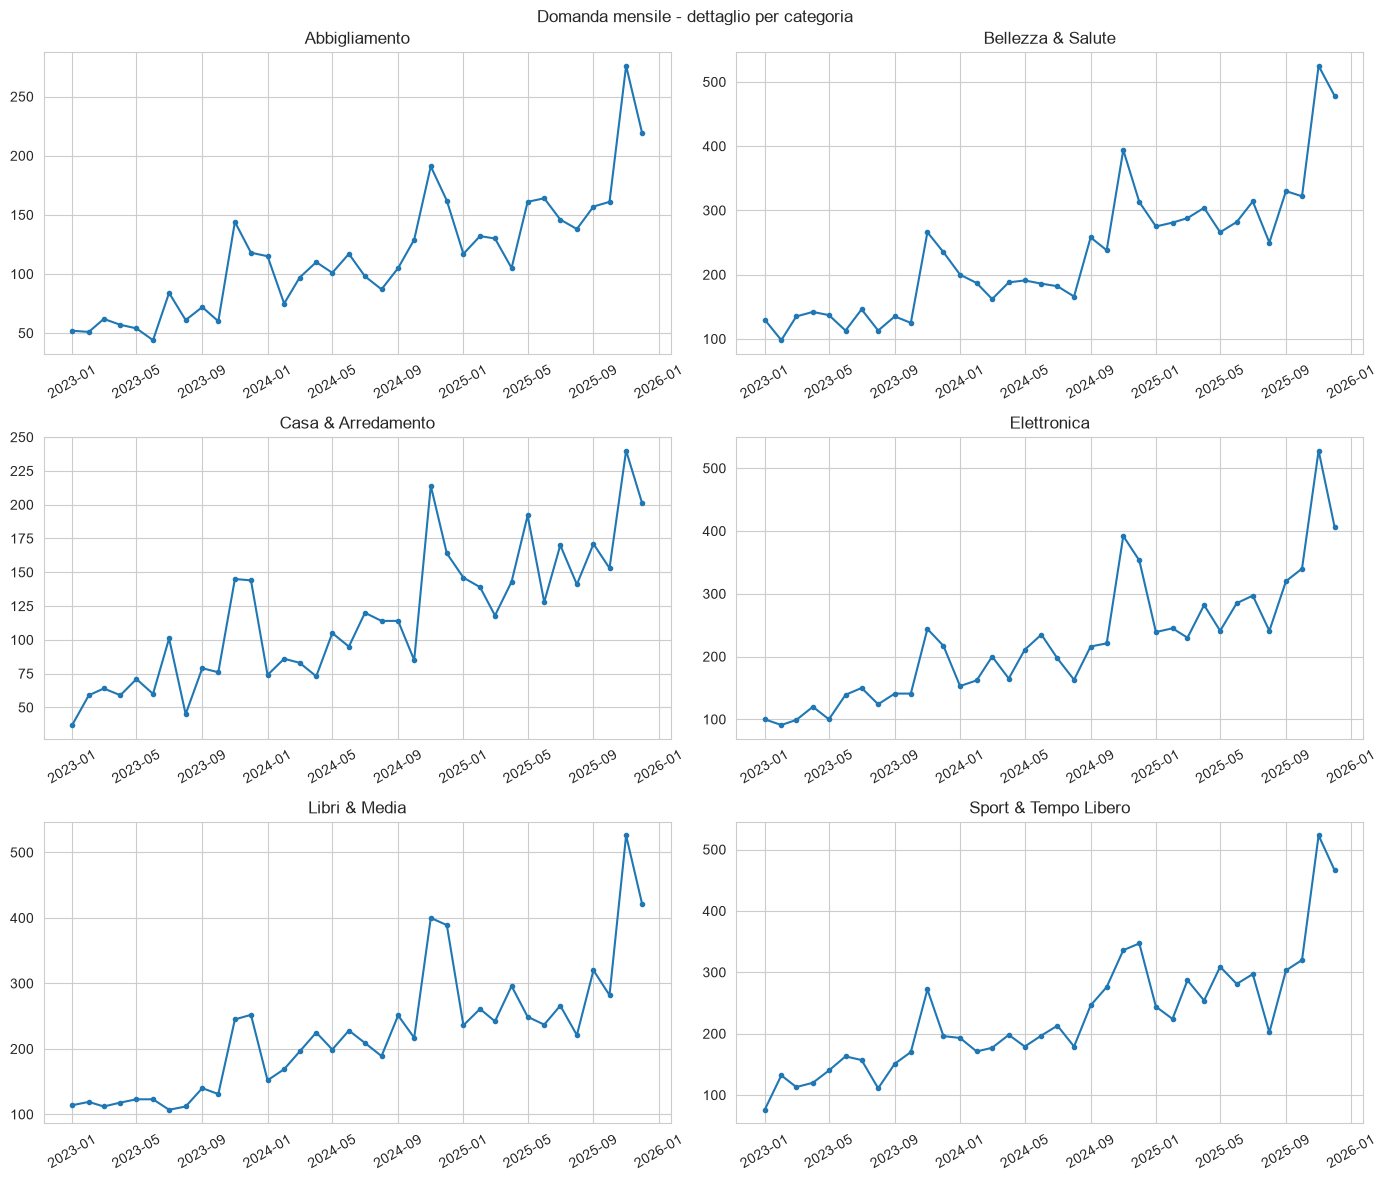


Grafici salvati nella cartella corrente (stessa dello script).


In [ ]:
"""
EDA - gold.vw_domanda_categoria_mensile

"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 140)

# ---------------------------------------------------------------
# 1. CARICAMENTO
# ---------------------------------------------------------------
df = pd.read_csv('Serie_Temporali.csv', sep=';', encoding='utf-8-sig')

df['data_mese'] = pd.to_datetime(df['data_mese'], format='%Y-%m-%d')

print("="*60)
print("SHAPE E INFO")
print("="*60)
print(df.shape)
df.info()

print("\n" + "="*60)
print("PRIME RIGHE")
print("="*60)
print(df.head(10))

# ---------------------------------------------------------------
# 2. NULL E DUPLICATI
# ---------------------------------------------------------------
print("\n" + "="*60)
print("NULL PER COLONNA")
print("="*60)
print(df.isnull().sum())

print("\nDuplicati (stessa categoria+mese ripetuti):")
print(df.duplicated(subset=['categoria', 'anno', 'mese']).sum())

# ---------------------------------------------------------------
# 3. QUANTE CATEGORIE E QUANTO STORICO PER CIASCUNA
# ---------------------------------------------------------------
print("\n" + "="*60)
print("CATEGORIE PRESENTI")
print("="*60)
print(df['categoria'].value_counts())

print("\n" + "="*60)
print("RANGE TEMPORALE PER CATEGORIA (min - max, numero di mesi osservati)")
print("="*60)
range_per_categoria = df.groupby('categoria')['data_mese'].agg(['min', 'max', 'count'])
print(range_per_categoria)

# ---------------------------------------------------------------
# 4. CONTROLLO BUCHI NELLA SERIE (fondamentale prima di calcolare i lag)
# ---------------------------------------------------------------
# Per ogni categoria, generiamo la sequenza di mesi "attesa" (dal primo
# all'ultimo mese osservato, senza salti) e la confrontiamo con quella reale.
print("\n" + "="*60)
print("CONTROLLO BUCHI NELLA SERIE TEMPORALE")
print("="*60)

buchi_trovati = False
for cat in df['categoria'].unique():
    sotto = df[df['categoria'] == cat].sort_values('data_mese')
    mesi_attesi = pd.date_range(sotto['data_mese'].min(), sotto['data_mese'].max(), freq='MS')
    mesi_mancanti = mesi_attesi.difference(sotto['data_mese'])
    if len(mesi_mancanti) > 0:
        buchi_trovati = True
        print(f"\n{cat}: {len(mesi_mancanti)} mesi mancanti -> {list(mesi_mancanti.strftime('%Y-%m'))}")

if not buchi_trovati:
    print("Nessun buco: tutte le categorie hanno una sequenza mensile continua.")

# ---------------------------------------------------------------
# 5. STATISTICHE DESCRITTIVE PER CATEGORIA
# ---------------------------------------------------------------
print("\n" + "="*60)
print("STATISTICHE DI quantita_totale_venduta PER CATEGORIA")
print("="*60)
print(df.groupby('categoria')['quantita_totale_venduta'].describe())

# ---------------------------------------------------------------
# 6. GRAFICI (salvati nella cartella corrente, nessuna sottocartella)
# ---------------------------------------------------------------
sns.set_style("whitegrid")

# 6.1 Andamento mensile, una linea per categoria - il grafico piu' importante:
# mostra trend e stagionalita' a colpo d'occhio
plt.figure(figsize=(14, 7))
for cat in sorted(df['categoria'].unique()):
    sotto = df[df['categoria'] == cat].sort_values('data_mese')
    plt.plot(sotto['data_mese'], sotto['quantita_totale_venduta'], marker='o', markersize=3, label=cat)
plt.title("Domanda mensile per categoria")
plt.xlabel("Mese")
plt.ylabel("Quantita' venduta")
plt.legend(title='Categoria', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("01_andamento_mensile_per_categoria.png", dpi=150)
plt.show()

# 6.2 Boxplot della quantita' per categoria (scala e outlier a confronto)
plt.figure(figsize=(10, 6))
sns.boxplot(x='categoria', y='quantita_totale_venduta', data=df)
plt.title("Distribuzione della domanda per categoria")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("02_boxplot_domanda_per_categoria.png", dpi=150)
plt.show()

# 6.3 Un pannello per categoria, per vedere meglio la stagionalita' individuale
# (nel grafico unico 6.1, categorie con volumi molto diversi si "schiacciano" a vicenda)
categorie = sorted(df['categoria'].unique())
n = len(categorie)
fig, axes = plt.subplots((n + 1) // 2, 2, figsize=(14, 4 * ((n + 1) // 2)))
axes = axes.flatten()
for ax, cat in zip(axes, categorie):
    sotto = df[df['categoria'] == cat].sort_values('data_mese')
    ax.plot(sotto['data_mese'], sotto['quantita_totale_venduta'], marker='o', markersize=3)
    ax.set_title(cat)
    ax.tick_params(axis='x', rotation=30)
for ax in axes[n:]:
    ax.set_visible(False)
plt.suptitle("Domanda mensile - dettaglio per categoria")
plt.tight_layout()
plt.savefig("03_dettaglio_per_categoria.png", dpi=150)
plt.show()

print("\nGrafici salvati nella cartella corrente (stessa dello script).")

SHAPE DOPO FEATURE ENGINEERING RIDOTTO
(144, 14)

Train: 126 righe, 12 feature
Test:  18 righe

PERFORMANCE DEL MODELLO (v2)

Train
  MAE:  13.42
  RMSE: 16.55
  R2:   0.954

Test
  MAE:  78.89
  RMSE: 102.00
  R2:   0.373

SCALA DI RIFERIMENTO
Media di quantita_totale_venduta (test):  354.83
Deviazione standard (test):                132.55

DETTAGLIO PREVISIONI SUL TEST SET
 data_mese            categoria  reale   previsto  errore
2025-10-01        Abbigliamento    161 175.600006   -14.6
2025-11-01        Abbigliamento    276 240.100006    35.9
2025-12-01        Abbigliamento    219 286.500000   -67.5
2025-10-01    Bellezza & Salute    322 313.100006     8.9
2025-11-01    Bellezza & Salute    525 341.799988   183.2
2025-12-01    Bellezza & Salute    478 342.100006   135.9
2025-10-01   Casa & Arredamento    153 144.699997     8.3
2025-11-01   Casa & Arredamento    240 257.299988   -17.3
2025-12-01   Casa & Arredamento    201 280.200012   -79.2
2025-10-01          Elettronica    340 32

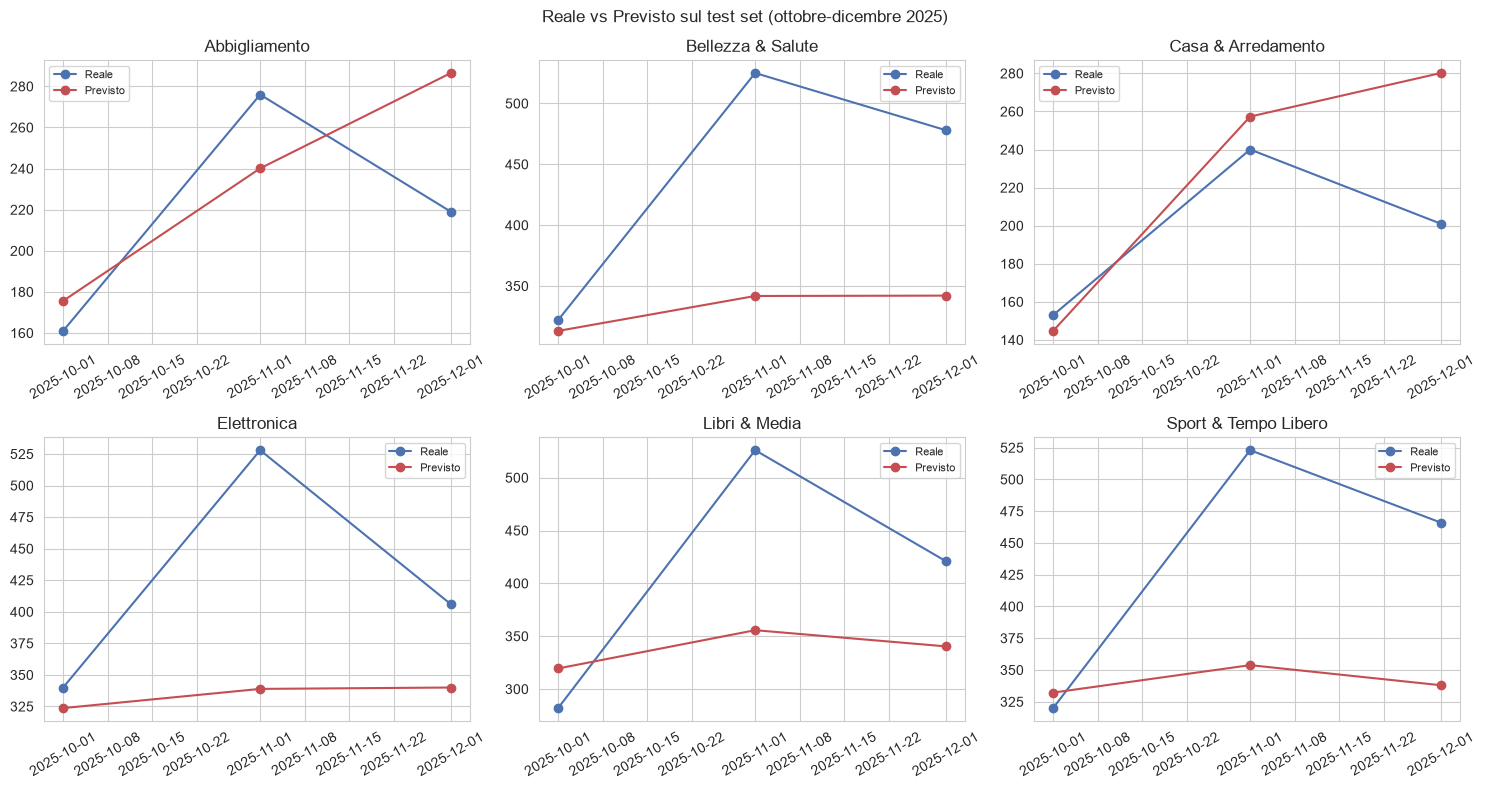

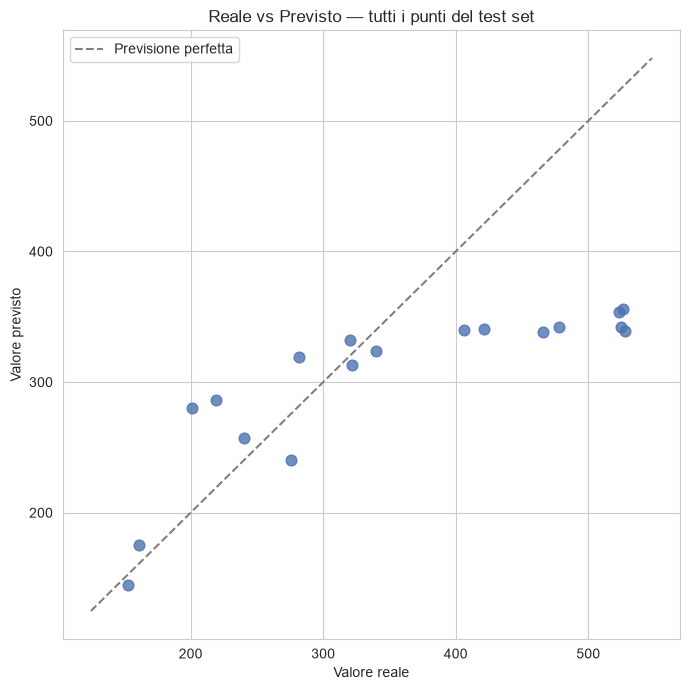

In [ ]:
"""
Training e Valutazione - Forecasting Domanda per Categoria (v2, anti-overfitting)

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.width', 140)

# ---------------------------------------------------------------
# 1. FEATURE ENGINEERING 
# ---------------------------------------------------------------

df['quarter'] = df['data_mese'].dt.quarter
df['lag_1'] = df.groupby('categoria')['quantita_totale_venduta'].shift(1)
df['lag_12'] = df.groupby('categoria')['quantita_totale_venduta'].shift(12)
df['rolling_mean_3'] = df.groupby('categoria')['quantita_totale_venduta'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)

df = pd.get_dummies(df, columns=['categoria'], prefix='cat')
df = df.dropna().reset_index(drop=True)

print("="*60)
print("SHAPE DOPO FEATURE ENGINEERING RIDOTTO")
print("="*60)
print(df.shape)

# ---------------------------------------------------------------
# 2. SPLIT CRONOLOGICO 
# ---------------------------------------------------------------
split_date = "2025-10-01"
train_mask = df['data_mese'] < split_date
test_mask = df['data_mese'] >= split_date

colonne_escluse = ['data_mese', 'quantita_totale_venduta']
feature_cols = [c for c in df.columns if c not in colonne_escluse]

X_train = df.loc[train_mask, feature_cols]
X_test = df.loc[test_mask, feature_cols]
y_train = df.loc[train_mask, 'quantita_totale_venduta']
y_test = df.loc[test_mask, 'quantita_totale_venduta']

print(f"\nTrain: {X_train.shape[0]} righe, {len(feature_cols)} feature")
print(f"Test:  {X_test.shape[0]} righe")

# ---------------------------------------------------------------
# 3. MODELLO 
# ---------------------------------------------------------------

model = XGBRegressor(
    n_estimators=60,
    learning_rate=0.1,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_lambda=5,
    reg_alpha=1,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

# ---------------------------------------------------------------
# 5. VALUTAZIONE — confronto train vs test
# ---------------------------------------------------------------
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n{label}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2:   {r2:.3f}")
    return mae, rmse, r2

train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

print("\n" + "="*60)
print("PERFORMANCE DEL MODELLO (v2)")
print("="*60)
evaluate(y_train, train_preds, "Train")
evaluate(y_test, test_preds, "Test")

print("\n" + "="*60)
print("SCALA DI RIFERIMENTO")
print("="*60)
print(f"Media di quantita_totale_venduta (test):  {y_test.mean():.2f}")
print(f"Deviazione standard (test):                {y_test.std():.2f}")

# ---------------------------------------------------------------
# 6. CONFRONTO PREVISTO VS REALE, RIGA PER RIGA
# ---------------------------------------------------------------
print("\n" + "="*60)
print("DETTAGLIO PREVISIONI SUL TEST SET")
print("="*60)
dettaglio = df.loc[test_mask, ['data_mese']].copy()
cat_cols = [c for c in feature_cols if c.startswith('cat_')]
dettaglio['categoria'] = df.loc[test_mask, cat_cols].idxmax(axis=1).str.replace('cat_', '')
dettaglio['reale'] = y_test.values
dettaglio['previsto'] = test_preds.round(1)
dettaglio['errore'] = (dettaglio['reale'] - dettaglio['previsto']).round(1)
print(dettaglio.sort_values(['categoria', 'data_mese']).to_string(index=False))

print("\n" + "="*60)
print("VALUTAZIONE ESCLUDENDO NOVEMBRE (limite di estrapolazione isolato)")
print("="*60)
# Novembre e' strutturalmente il mese dove il modello "sbatte" contro il
# massimo storico visto in training (il picco di fine anno cresce ogni anno).
# Escludendolo, vediamo quanto e' buono il modello sui mesi "normali".
mask_no_novembre = dettaglio['data_mese'] != '2025-11-01'
y_test_no_nov = dettaglio.loc[mask_no_novembre, 'reale']
pred_no_nov = dettaglio.loc[mask_no_novembre, 'previsto']

evaluate(y_test_no_nov, pred_no_nov, "Test (senza novembre)")

print(f"\nRighe incluse: {mask_no_novembre.sum()} su {len(dettaglio)} (ottobre + dicembre, tutte le categorie)")

# ---------------------------------------------------------------
# 7. FEATURE IMPORTANCE
# ---------------------------------------------------------------
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)
importances = pd.Series(model.feature_importances_, index=feature_cols)
print(importances.sort_values(ascending=False))

# ---------------------------------------------------------------
# 8. GRAFICI — reale vs previsto
# ---------------------------------------------------------------
# 8.1 Un pannello per categoria: linea reale e linea prevista sui 3 mesi di test.
# Rende visibile a colpo d'occhio dove il modello si "appiattisce" (novembre/
# dicembre per le categorie ad alto volume) invece di seguire il dato reale.
categorie_ordinate = sorted(dettaglio['categoria'].unique())
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, cat in zip(axes, categorie_ordinate):
    sotto = dettaglio[dettaglio['categoria'] == cat].sort_values('data_mese')
    ax.plot(sotto['data_mese'], sotto['reale'], marker='o', label='Reale', color='#4C72B0')
    ax.plot(sotto['data_mese'], sotto['previsto'], marker='o', label='Previsto', color='#C44E52')
    ax.set_title(cat)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.suptitle("Reale vs Previsto sul test set (ottobre-dicembre 2025)")
plt.tight_layout()
plt.savefig("04_reale_vs_previsto_per_categoria.png", dpi=150)
plt.show()

# 8.2 Scatter reale vs previsto con diagonale di riferimento.
# Se le previsioni fossero perfette, tutti i punti cadrebbero sulla diagonale.
# Punti sopra la diagonale (previsto < reale) = il modello sottostima,
# esattamente il pattern atteso per i valori che superano il massimo storico.
plt.figure(figsize=(7, 7))
plt.scatter(dettaglio['reale'], dettaglio['previsto'], s=60, alpha=0.8, color='#4C72B0')
lim_min = min(dettaglio['reale'].min(), dettaglio['previsto'].min()) - 20
lim_max = max(dettaglio['reale'].max(), dettaglio['previsto'].max()) + 20
plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle='--', color='gray', label='Previsione perfetta')
plt.xlabel("Valore reale")
plt.ylabel("Valore previsto")
plt.title("Reale vs Previsto — tutti i punti del test set")
plt.legend()
plt.tight_layout()
plt.savefig("05_scatter_reale_vs_previsto.png", dpi=150)
plt.show()

           categoria  data_mese  quantita_totale_venduta
       Abbigliamento 2026-01-01               196.086060
       Abbigliamento 2026-02-01               196.064133
       Abbigliamento 2026-03-01               181.141479
   Bellezza & Salute 2026-01-01               296.256042
   Bellezza & Salute 2026-02-01               309.348846
   Bellezza & Salute 2026-03-01               312.642487
  Casa & Arredamento 2026-01-01               188.591187
  Casa & Arredamento 2026-02-01               181.457504
  Casa & Arredamento 2026-03-01               179.114258
         Elettronica 2026-01-01               278.817474
         Elettronica 2026-02-01               294.367615
         Elettronica 2026-03-01               268.154327
       Libri & Media 2026-01-01               259.378174
       Libri & Media 2026-02-01               292.270294
       Libri & Media 2026-03-01               274.249603
Sport & Tempo Libero 2026-01-01               290.996460
Sport & Tempo Libero 2026-02-01

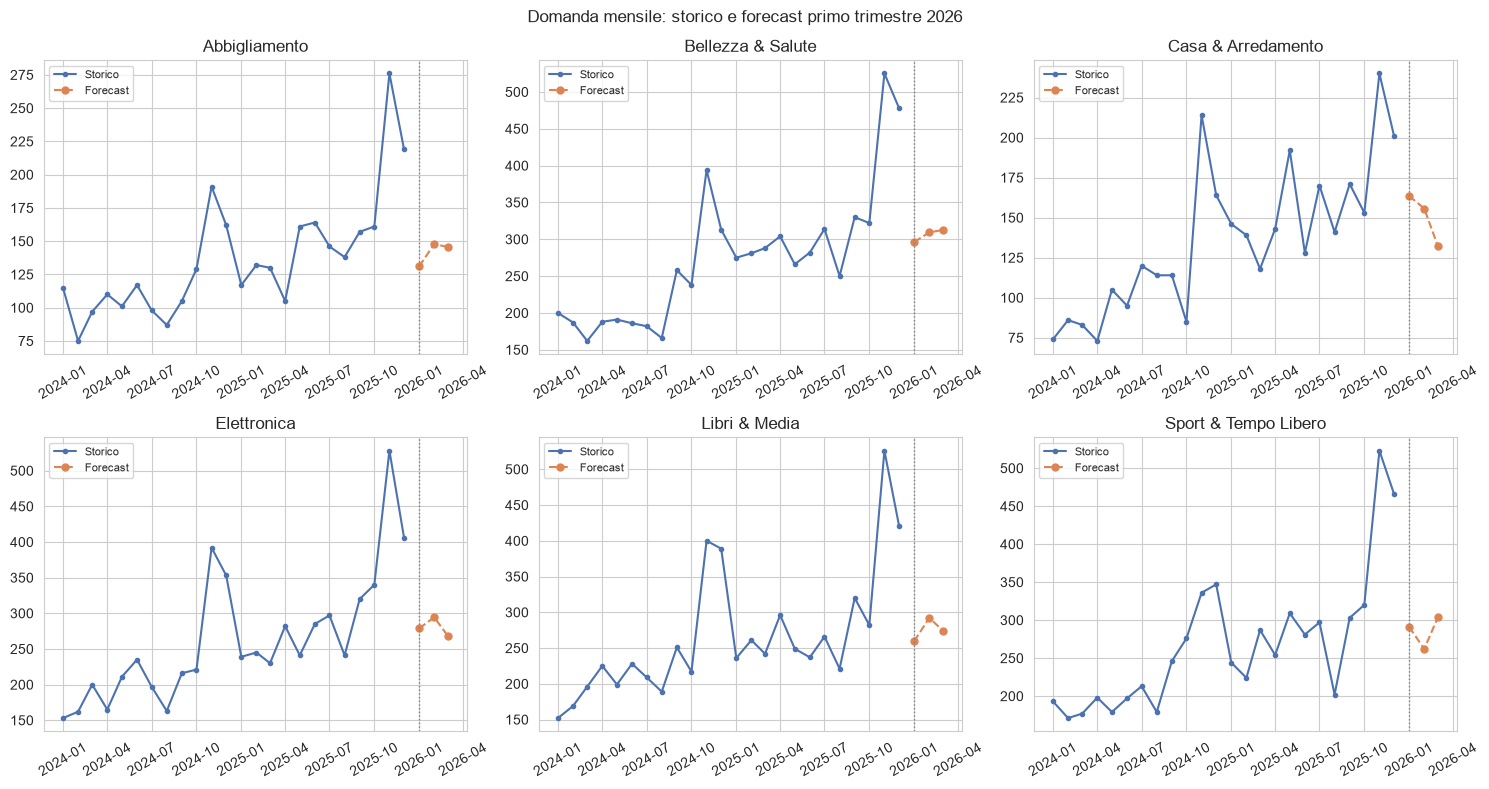

In [ ]:
# ---------------------------------------------------------------
# 2. RIADDESTRAMENTO SU TUTTI I DATI
# ---------------------------------------------------------------
feature_cols = [c for c in df.columns if c not in ['data_mese', 'quantita_totale_venduta']]
cat_cols = [c for c in feature_cols if c.startswith('cat_')]
categorie = [c.replace('cat_', '') for c in cat_cols]

model = XGBRegressor(
    n_estimators=60, learning_rate=0.1, max_depth=3, min_child_weight=3,
    subsample=0.8, colsample_bytree=0.7, reg_lambda=5, reg_alpha=1,
    objective="reg:squarederror", random_state=42
)
model.fit(df[feature_cols], df['quantita_totale_venduta'])

# ---------------------------------------------------------------
# 3. FORECASTING RICORSIVO — 3 mesi, per ciascuna categoria
# ---------------------------------------------------------------
future_predictions = []

for cat in categorie:
    # Filtriamo usando la colonna one-hot (== True), non piu' 'categoria' == cat
    last_data = df[df[f'cat_{cat}'] == True].sort_values('data_mese').copy()

    for i in range(3):
        last_row = last_data.iloc[-1:]
        next_month = last_row["data_mese"].values[0] + pd.DateOffset(months=1)

        new_row = pd.DataFrame({
            "anno": [next_month.year],
            "mese": [next_month.month],
            "quarter": [next_month.quarter],
            "lag_1": last_row["quantita_totale_venduta"].values,
            "lag_12": [last_data["quantita_totale_venduta"].iloc[-12]],
            "rolling_mean_3": [last_data["quantita_totale_venduta"].iloc[-3:].mean()],
        })
        for c in cat_cols:
            new_row[c] = (c == f"cat_{cat}")

        pred = model.predict(new_row[feature_cols])[0]
        new_row["categoria"] = cat
        new_row["data_mese"] = next_month
        new_row["quantita_totale_venduta"] = int(round(pred))

        future_predictions.append(new_row)
        last_data = pd.concat([last_data, new_row], ignore_index=True)

future_df = pd.concat(future_predictions)[["categoria", "data_mese", "quantita_totale_venduta"]]
print(future_df.sort_values(["categoria", "data_mese"]).to_string(index=False))

# ---------------------------------------------------------------
# CORREZIONE MANUALE per le 2 categorie con forecasting anomalo
# ---------------------------------------------------------------

future_df['quantita_totale_venduta'] = future_df['quantita_totale_venduta'].astype('float64')

categorie_da_correggere = ['Abbigliamento', 'Casa & Arredamento']
fattore_crescita = 1.12  # punto medio della forbice 10-15% raccomandata

for cat in categorie_da_correggere:
    for mese in [1, 2, 3]:
        valore_anno_scorso = df[
            (df[f'cat_{cat}'] == True) &
            (df['data_mese'].dt.year == 2025) &
            (df['data_mese'].dt.month == mese)
        ]['quantita_totale_venduta'].values[0]

        valore_corretto = int(round(valore_anno_scorso * fattore_crescita))

        maschera = (
            (future_df['categoria'] == cat) &
            (future_df['data_mese'].dt.month == mese)
        )
        future_df.loc[maschera, 'quantita_totale_venduta'] = valore_corretto

print(future_df.sort_values(["categoria", "data_mese"]).to_string(index=False))

# ---------------------------------------------------------------
# 4. GRAFICO — storico (fino a dicembre 2025) + forecast (gen-mar 2026)
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
 
for ax, cat in zip(axes, categorie):
    storico = df[df[f'cat_{cat}'] == True].sort_values('data_mese')
    previsto = future_df[future_df['categoria'] == cat].sort_values('data_mese')
 
    ax.plot(storico['data_mese'], storico['quantita_totale_venduta'],
            marker='o', markersize=3, label='Storico', color='#4C72B0')
    ax.plot(previsto['data_mese'], previsto['quantita_totale_venduta'],
            marker='o', markersize=5, linestyle='--', label='Forecast', color='#DD8452')
    ax.axvline(pd.to_datetime('2026-01-01'), color='gray', linestyle=':', linewidth=1)
    ax.set_title(cat)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
 
plt.suptitle("Domanda mensile: storico e forecast primo trimestre 2026")
plt.tight_layout()
plt.savefig("06_storico_e_forecast.png", dpi=150)
plt.show()

future_df.to_csv('Forecasting.csv', sep=';', index=False)